# MOMARL Render Plots — HAPPO vs MAPPO Comparison

Plots render data produced by `JusticeEnvironmentMOMA.render()`.

**Data layout expected:**
```
results/detailed_analysis/evaluation/
  happo/
    happo_w*/   ← one folder per weight vector
  mappo/
    mappo_w*/
```

Each run folder contains `{algo}_idx{N}_{scenario}_{variable}.npy` files and an `objective_summary.csv`.


In [23]:

from pathlib import Path
import json
import re as _re
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from justice.util.visualizer import (
    plot_comparison_with_boxplots,
    plot_emissions_comparison_with_boxplots,
    plot_choropleth_2D_data,
    plot_stacked_area_chart_with_baseline_emissions,
    plot_median_emission_comparison_with_baseline,
    plot_regional_emissions_with_boxplots,
    plot_emission_control_rate,
)
from justice.util.data_loader import DataLoader
from justice.util.model_time import TimeHorizon
from justice.util.regional_configuration import get_region_mapping


In [24]:
# ── Configuration ─────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'justice').exists():
    REPO_ROOT = Path('/home/olaand/JUSTICE').resolve()
os.chdir(REPO_ROOT)

SCENARIO = 'SSP245'

EVAL_ROOT  = REPO_ROOT / 'results/detailed_analysis/evaluation'
HAPPO_ROOT = EVAL_ROOT / 'happo'
MAPPO_ROOT = EVAL_ROOT / 'mappo'

BASELINE_PATH = REPO_ROOT / 'data/temporary/baseline_emissions_16.npy'

# ── Weight selection ──────────────────────────────────────────────────────────
# Set to a list of integer weight IDs to restrict which runs are plotted,
# or None to include all discovered runs.
HAPPO_WEIGHTS = [23, 64, 69, 82, 99]       # e.g. [64, 82] or None for all
MAPPO_WEIGHTS = [42, 52, 80, 88]       # e.g. [52, 80] or None for all

# Algorithm colour palette (fill / line)
HAPPO_COLOR = 'rgba(252, 141, 98, 0.25)'
MAPPO_COLOR = 'rgba(141, 160, 203, 0.25)'
HAPPO_LINE  = 'rgba(252, 141, 98, 1)'
MAPPO_LINE  = 'rgba(141, 160, 203, 1)'


# ── Helpers ───────────────────────────────────────────────────────────────────
def discover_runs(algo_root: Path) -> dict[str, Path]:
    """Return {run_name: run_dir} for all weight subdirectories."""
    return {p.name: p for p in sorted(algo_root.iterdir()) if p.is_dir()}


def filter_runs(runs: dict, weights: list | None) -> dict[str, Path]:
    """Keep only runs whose name ends with _w<N> for N in *weights*.
    If *weights* is None, return all runs unchanged."""
    if weights is None:
        return runs
    keep = {f'_w{w}' for w in weights}
    return {name: path for name, path in runs.items()
            if any(name.endswith(k) for k in keep)}


def latest_export_info(run_dir: Path, scenario: str = SCENARIO) -> dict:
    """Find the highest-index export prefix inside *run_dir*."""
    candidates = list(run_dir.glob(f'*_idx*_{scenario}_global_temperature.npy'))
    if not candidates:
        raise FileNotFoundError(f'No {scenario} exports in {run_dir}')

    def _parse(path: Path):
        prefix = path.stem.rsplit(f'_{scenario}_global_temperature', 1)[0]
        idx = int(prefix.split('_idx')[-1])
        return idx, prefix

    idx, prefix = max((_parse(p) for p in candidates), key=lambda x: x[0])
    return {'idx': idx, 'prefix': prefix}


def npy_path(run_dir: Path, prefix: str, variable: str, scenario: str = SCENARIO) -> str:
    return str(run_dir / f'{prefix}_{scenario}_{variable}.npy')


# ── Discover & filter runs ────────────────────────────────────────────────────
happo_runs = filter_runs(discover_runs(HAPPO_ROOT), HAPPO_WEIGHTS)
mappo_runs = filter_runs(discover_runs(MAPPO_ROOT), MAPPO_WEIGHTS)
happo_info = {name: latest_export_info(d) for name, d in happo_runs.items()}
mappo_info = {name: latest_export_info(d) for name, d in mappo_runs.items()}

happo_labels = [f'HAPPO {n} (idx {happo_info[n]["idx"]})' for n in happo_runs]
mappo_labels = [f'MAPPO {n} (idx {mappo_info[n]["idx"]})' for n in mappo_runs]

all_labels = happo_labels + mappo_labels
all_colors = [HAPPO_COLOR] * len(happo_runs) + [MAPPO_COLOR] * len(mappo_runs)
all_lines  = [HAPPO_LINE]  * len(happo_runs) + [MAPPO_LINE]  * len(mappo_runs)

print('REPO_ROOT  :', REPO_ROOT)
print(f'HAPPO runs : {list(happo_runs)}')
print(f'MAPPO runs : {list(mappo_runs)}')


REPO_ROOT  : /home/olaand/JUSTICE
HAPPO runs : ['happo_w23', 'happo_w64', 'happo_w69', 'happo_w82', 'happo_w99']
MAPPO runs : ['mappo_w42', 'mappo_w52', 'mappo_w80', 'mappo_w88']


In [28]:

# ── Shared region-mapping loader (cached) ─────────────────────────────────────
_CLUSTER_CACHE = {}

def _load_cluster_mapping():
    if _CLUSTER_CACHE:
        return _CLUSTER_CACHE['code_to_cluster'], _CLUSTER_CACHE['clusters']
    dl = DataLoader()
    region_codes = list(dl.REGION_LIST)
    with open('data/input/rice_12_regions_dict.json') as f:
        rice_12 = json.load(f)
    with open('data/input/rice50_regions_dict.json') as f:
        rice_50 = json.load(f)
    code_to_cluster = {}
    for rice50_code, iso_codes in rice_50.items():
        for iso in iso_codes:
            for cluster_name, cluster_isos in rice_12.items():
                if iso in cluster_isos:
                    code_to_cluster[rice50_code] = cluster_name
                    break
            if rice50_code in code_to_cluster:
                break
    clusters = sorted(rice_12.keys())
    _CLUSTER_CACHE.update(code_to_cluster=code_to_cluster, clusters=clusters,
                          region_codes=region_codes)
    return code_to_cluster, clusters


def _cluster_color_map():
    code_to_cluster, clusters = _load_cluster_mapping()
    _base = px.colors.qualitative.Set1 + px.colors.qualitative.Dark2
    return {c: _base[i % len(_base)] for i, c in enumerate(clusters)}


def plot_grouped_control_rate_grid(
    npy_paths: list[str],
    subplot_titles: list[str],
    suptitle: str = '',
    variable_label: str = 'Rate',
    start_year: int = 2015,
    end_year: int = 2300,
    data_timestep: int = 5,
    timestep: int = 1,
    viz_start_year: int = 2025,
    viz_end_year: int = 2100,
    yaxis_range: list = None,
    ncols: int = 3,
    template: str = 'plotly_white',
) -> go.Figure:
    """Grid of per-region control-rate line plots, one subplot per weight run."""
    code_to_cluster, clusters = _load_cluster_mapping()
    region_codes = _CLUSTER_CACHE['region_codes']
    color_map = _cluster_color_map()

    th = TimeHorizon(start_year=start_year, end_year=end_year,
                     data_timestep=data_timestep, timestep=timestep)
    all_years = th.model_time_horizon
    year_cols = [y for y in all_years if viz_start_year <= y <= viz_end_year]

    n = len(npy_paths)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=subplot_titles,
                        shared_yaxes=True, shared_xaxes=True,
                        horizontal_spacing=0.03, vertical_spacing=0.08)

    legend_added = set()
    for idx, path in enumerate(npy_paths):
        row = idx // ncols + 1
        col = idx % ncols + 1

        data = np.load(path)
        if data.ndim == 3:
            data = data.mean(axis=2)

        df = pd.DataFrame(data, index=region_codes, columns=all_years)
        df = df[year_cols].copy()
        df['cluster'] = [code_to_cluster.get(c, 'Other') for c in region_codes]

        for cluster in clusters:
            sub = df[df['cluster'] == cluster]
            if sub.empty:
                continue
            vals = sub[year_cols].iloc[0].values
            show = cluster not in legend_added
            fig.add_trace(go.Scatter(
                x=year_cols, y=vals, mode='lines',
                line=dict(color=color_map[cluster], width=1.5),
                name=cluster, legendgroup=cluster,
                showlegend=show,
                hovertemplate=(f'<b>{cluster}</b><br>'
                               f'{variable_label}: %{{y:.3f}}<extra></extra>'),
            ), row=row, col=col)
            legend_added.add(cluster)

        if yaxis_range:
            fig.update_yaxes(range=yaxis_range, row=row, col=col)

    # Fit inside VS Code notebook viewport (~960px wide)
    fig.update_layout(
        title=dict(text=suptitle, font=dict(size=14)),
        template=template,
        width=960,
        height=280 * nrows + 60,
        margin=dict(l=40, r=140, t=50, b=30),
        legend=dict(title='Region', font=dict(size=10),
                    bgcolor='rgba(255,255,255,0.85)',
                    bordercolor='lightgrey', borderwidth=1,
                    x=1.01, y=1, xanchor='left'),
        hovermode='x',
    )
    fig.update_xaxes(tickfont=dict(size=9))
    fig.update_yaxes(tickfont=dict(size=9))
    # Style subplot titles
    for ann in fig['layout']['annotations']:
        ann['font'] = dict(size=11)

    return fig


In [29]:

## Emission Control Rate by Region (grid per algorithm)

for algo, runs, info in [('HAPPO', happo_runs, happo_info), ('MAPPO', mappo_runs, mappo_info)]:
    paths, titles = [], []
    for run_name, run_dir in runs.items():
        paths.append(npy_path(run_dir, info[run_name]['prefix'], 'constrained_emission_control_rate'))
        titles.append(run_name)
    fig = plot_grouped_control_rate_grid(
        npy_paths=paths,
        subplot_titles=titles,
        suptitle=f'Emission Control Rate — {algo}',
        variable_label='ECR',
        yaxis_range=[0, 1],
    )
    fig.show()


In [30]:

## Savings Rate by Region (grid per algorithm)

for algo, runs, info in [('HAPPO', happo_runs, happo_info), ('MAPPO', mappo_runs, mappo_info)]:
    paths, titles = [], []
    for run_name, run_dir in runs.items():
        paths.append(npy_path(run_dir, info[run_name]['prefix'], 'constrained_savings_rate'))
        titles.append(run_name)
    fig = plot_grouped_control_rate_grid(
        npy_paths=paths,
        subplot_titles=titles,
        suptitle=f'Savings Rate — {algo}',
        variable_label='Savings Rate',
        yaxis_range=[0, 1],
    )
    fig.show()


In [31]:
## Plot 1 — Global Temperature: HAPPO vs MAPPO

happo_temp_paths = [
    npy_path(happo_runs[n], happo_info[n]['prefix'], 'global_temperature')
    for n in happo_runs
]
mappo_temp_paths = [
    npy_path(mappo_runs[n], mappo_info[n]['prefix'], 'global_temperature')
    for n in mappo_runs
]

fig_temp = plot_comparison_with_boxplots(
    data_paths=happo_temp_paths + mappo_temp_paths,
    labels=all_labels,
    start_year=2015,
    end_year=2300,
    data_timestep=5,
    timestep=1,
    visualization_start_year=2025,
    visualization_end_year=2299,
    yaxis_range=[0.5, 5],
    plot_title='Global Temperature — HAPPO vs MAPPO',
    output_path='.',
    xaxis_title='Year',
    yaxis_title='Global Temperature (°C)',
    template='plotly_white',
    width=1200,
    height=700,
    colors=all_colors,
    linecolors=all_lines,
    show_red_dashed_line=False,
    saving=False,
    show_interquartile_range=True,
    transpose_data=True,
)
fig_temp.show()


In [32]:
## Plot 2 — Global Emissions: HAPPO vs MAPPO

happo_em_paths = [
    npy_path(happo_runs[n], happo_info[n]['prefix'], 'emissions')
    for n in happo_runs
]
mappo_em_paths = [
    npy_path(mappo_runs[n], mappo_info[n]['prefix'], 'emissions')
    for n in mappo_runs
]

fig_emissions = plot_emissions_comparison_with_boxplots(
    data_paths=happo_em_paths + mappo_em_paths,
    start_year=2015,
    end_year=2300,
    data_timestep=5,
    timestep=1,
    visualization_start_year=2025,
    visualization_end_year=2299,
    yaxis_range=[0, 80],
    opacity=0.2,
    plot_title='Global Emissions — HAPPO vs MAPPO',
    xaxis_title='Year',
    yaxis_title='Global Emissions (GtCO₂/year)',
    template='plotly_white',
    width=1200,
    height=700,
    baseline_path=str(BASELINE_PATH) if BASELINE_PATH.exists() else None,
    output_path='.',
    saving=False,
    colors=all_colors,
    median_colors=all_lines,
)
fig_emissions.show()


## Plot 3 — Median Emission Pathways vs Baseline

Best HAPPO run vs best MAPPO run, compared against the SSP2-4.5 baseline.

> **Best run** = the run whose `objective_summary.csv` records the highest `welfare`.  
> Falls back to the first discovered run if the CSV is missing.


In [ ]:
def _best_run(runs: dict, info: dict) -> str:
    """Return the name of the run with highest welfare, or the first run."""
    scores = {}
    for name, run_dir in runs.items():
        csv = run_dir / 'objective_summary.csv'
        if csv.exists():
            df = pd.read_csv(csv)
            if 'welfare' in df.columns:
                scores[name] = df['welfare'].max()
                print(df['welfare'])
    return max(scores, key=scores.get) if scores else next(iter(runs))


best_happo = _best_run(happo_runs, happo_info)
best_mappo = _best_run(mappo_runs, mappo_info)

print(f'Best HAPPO run: {best_happo}')
print(f'Best MAPPO run: {best_mappo}')

if BASELINE_PATH.exists():
    median_paths = [
        str(BASELINE_PATH),
        npy_path(happo_runs[best_happo], happo_info[best_happo]['prefix'], 'emissions'),
        npy_path(mappo_runs[best_mappo], mappo_info[best_mappo]['prefix'], 'emissions'),
    ]
    median_labels = ['SSP2-Baseline', f'HAPPO {best_happo}', f'MAPPO {best_mappo}']

    fig_median, _ = plot_median_emission_comparison_with_baseline(
        data_paths=median_paths,
        labels=median_labels,
        fill=['none', 'none', 'none'],
        path_to_output='.',
        xaxis_title='Year',
        yaxis_title='CO₂ emissions (GtCO₂/year)',
        linewidth=3,
        colour_palette=['#7F7F7F', HAPPO_LINE, MAPPO_LINE],
        template='plotly_white',
        yaxis_upper_limit=70,
        visualization_start_year=2024,
        visualization_end_year=2299,
        width=1000,
        height=800,
        fontsize=15,
        saving=False,
    )
    fig_median.show()
else:
    print(f'Baseline not found at {BASELINE_PATH}. Set BASELINE_PATH in the config cell.')


Best HAPPO run: happo_w99
Best MAPPO run: mappo_w80


## Plot 4 — Regional Emission Envelopes: Best HAPPO vs Best MAPPO

Per-region emission envelopes for the best run of each algorithm.  
Adjust `REGION_INDICES` as needed (paper uses RICE-50 indices `[9, 28, 54, 43]`).


In [16]:
## Plot 4 — Regional Emissions: best HAPPO vs best MAPPO

REGION_INDICES = [9, 28, 54, 43]

happo_em_path = npy_path(happo_runs[best_happo], happo_info[best_happo]['prefix'], 'emissions')
mappo_em_path = npy_path(mappo_runs[best_mappo], mappo_info[best_mappo]['prefix'], 'emissions')

for region in REGION_INDICES:
    fig = plot_regional_emissions_with_boxplots(
        utilitarian_path=happo_em_path,    # HAPPO plays the role of "utilitarian"
        prioritarian_path=mappo_em_path,   # MAPPO plays the role of "prioritarian"
        start_year=2015,
        end_year=2300,
        data_timestep=5,
        timestep=1,
        visualization_start_year=2025,
        visualization_end_year=2100,
        region_index=region,
        yaxis_range=[0, 15],
        opacity=0.07,
        plot_title=f'Emissions — HAPPO ({best_happo}) vs MAPPO ({best_mappo}) | Region {region}',
        xaxis_title='Year',
        yaxis_title='Emissions (GtCO₂/year)',
        template='plotly_white',
        width=1200,
        height=800,
        color_palette=[HAPPO_LINE, MAPPO_LINE],
        output_path='.',
        saving=False,
    )
    #fig.show()


In [17]:
## Plot 5 — Emission Control Rate Choropleth (2050)

# One choropleth per algorithm, each showing all its runs side-by-side
for algo, runs, info in [('HAPPO', happo_runs, happo_info), ('MAPPO', mappo_runs, mappo_info)]:
    algo_root = HAPPO_ROOT if algo == 'HAPPO' else MAPPO_ROOT
    for run_name in runs:
        input_data_path = (
            f'{run_name}/{info[run_name]["prefix"]}_{SCENARIO}_constrained_emission_control_rate.npy'
        )
        fig, _ = plot_choropleth_2D_data(
            path_to_data=str(algo_root) + '/',
            path_to_output='../thesis_rl/evaluation/choropleth_outputs',
            projection='natural earth1',
            colourmap=px.colors.sequential.Reds,
            year_to_visualize=2050,
            input_data_path_list=[input_data_path],
            title=f'Emission Control Rate (2050) — {algo} {run_name}',
            output_titles=[''],
            data_label='Emission Control Rate',
            legend_label='',
            data_normalization=True,
            saving=False,
            show_colorbar=True,
            normalized_colorbar=True,
        )
        fig.show()


Taking average over the last dimension.
0


Taking average over the last dimension.
0


In [18]:
## Plot 6 — Regional Emission Stacked-Area Chart (best HAPPO vs best MAPPO)

region_dict = json.load(open(REPO_ROOT / 'data/input/9_regions.json'))

REGION_COLOURS = [
    'rgb(149,150,160)',  'rgb(149,150,160,0.2)',
    'rgb(247,129,191)',  'rgb(247,129,191,0.2)',
    'rgb(166,86,40)',    'rgb(166,86,40,0.2)',
    'rgb(255,255,51)',   'rgb(255,255,51,0.2)',
    'rgb(255,127,0)',    'rgb(255,127,0,0.2)',
    'rgb(152,78,163)',   'rgb(152,78,163,0.2)',
    'rgb(77,175,74)',    'rgb(77,175,74,0.2)',
    'rgb(55,126,184)',   'rgb(55,126,184,0.2)',
    'rgb(228,26,28)',    'rgb(228,26,28,0.2)',
]
REGIONAL_ORDER = [
    'Rest of the World', 'Rest of the World_abated',
    'Europe', 'Europe_abated',
    'Gulf Countries', 'Gulf Countries_abated',
    'South and Southeast Asia', 'South and Southeast Asia_abated',
    'Other High Income', 'Other High Income_abated',
    'Sub-Saharan Africa', 'Sub-Saharan Africa_abated',
    'China', 'China_abated',
    'India', 'India_abated',
    'United States', 'United States_abated',
]

for algo, runs, info, algo_root in [
    ('HAPPO', happo_runs, happo_info, HAPPO_ROOT),
    ('MAPPO', mappo_runs, mappo_info, MAPPO_ROOT),
]:
    for run_name in runs:
        fig, _, _ = plot_stacked_area_chart_with_baseline_emissions(
            variable_name='emissions',
            filetype='.npy',
            path_to_data=str(algo_root),
            baseline_emissions_path=str(BASELINE_PATH),
            input_data=[f'{run_name}/{info[run_name]["prefix"]}'],
            output_titles=[f'{algo} {run_name}'],
            scenario_list=[SCENARIO],
            title=f'Regional Emissions — {algo} {run_name} vs Baseline',
            xaxis_label='Year',
            yaxis_label='',
            height=800,
            width=1200,
            visualization_start_year=2025,
            visualization_end_year=2100,
            plot_title=' ',
            groupnorm='percent',
            colour_palette=REGION_COLOURS,
            region_dict=region_dict,
            saving=False,
            yaxis_lower_limit=0,
            yaxis_upper_limit=16,
            regional_order=REGIONAL_ORDER,
        )
        fig.show()


Loading data for:  SSP245  -  happo_w64/happo_idx0
Baseline emissions shape:  (57, 286, 15)
Data shape:  (57, 286, 15)
Region list:  ['Rest of the World', 'Europe', 'Sub-Saharan Africa', 'Gulf Countries', 'Other High Income', 'South and Southeast Asia', 'China', 'India', 'United States']


Loading data for:  SSP245  -  mappo_w52/mappo_idx0
Baseline emissions shape:  (57, 286, 15)
Data shape:  (57, 286, 15)
Region list:  ['Rest of the World', 'Europe', 'Sub-Saharan Africa', 'Gulf Countries', 'Other High Income', 'South and Southeast Asia', 'China', 'India', 'United States']


,algorithm,run_name,welfare,final_global_temperature,years_above_temperature_threshold,num_agents,num_objectives
1,HAPPO,happo_w64,-145.509006,2.037257,110,12,2
2,MAPPO,mappo_w52,-142.396743,2.266094,176,12,2


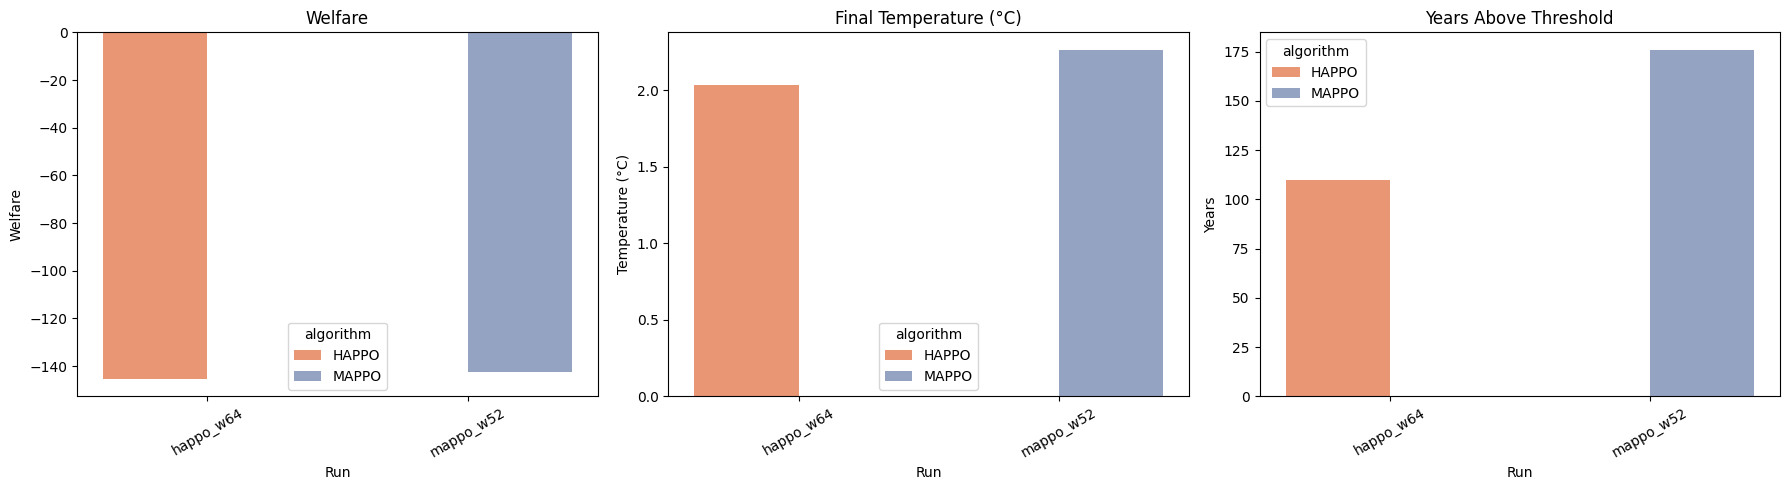

In [19]:
## Plot 7 — Objective Summary: HAPPO vs MAPPO

def _load_summary(runs: dict, algo: str) -> pd.DataFrame:
    frames = []
    for run_name, run_dir in runs.items():
        csv = run_dir / 'objective_summary.csv'
        if csv.exists():
            df = pd.read_csv(csv)
            df['run_name'] = run_name
            df['algorithm'] = algo
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


happo_summary = _load_summary(happo_runs, 'HAPPO')
mappo_summary = _load_summary(mappo_runs, 'MAPPO')
all_summary   = pd.concat([happo_summary, mappo_summary], ignore_index=True)

all_summary['timestamp_utc'] = pd.to_datetime(all_summary['timestamp_utc'], errors='coerce')
latest_summary = (
    all_summary.sort_values('timestamp_utc')
    .groupby(['algorithm', 'run_name'], as_index=False)
    .tail(1)
    .sort_values(['algorithm', 'run_name'])
)

display(
    latest_summary[[
        'algorithm', 'run_name',
        'welfare', 'final_global_temperature', 'years_above_temperature_threshold',
        'num_agents', 'num_objectives',
    ]]
)

BAR_METRICS = [
    ('welfare',                       'Welfare',                    'Welfare'),
    ('final_global_temperature',      'Final Temperature (°C)',     'Temperature (°C)'),
    ('years_above_temperature_threshold', 'Years Above Threshold', 'Years'),
]
palette = {'HAPPO': '#fc8d62', 'MAPPO': '#8da0cb'}

fig, axes = plt.subplots(1, len(BAR_METRICS), figsize=(6 * len(BAR_METRICS), 5))
for ax, (metric, title, y_label) in zip(np.atleast_1d(axes), BAR_METRICS):
    if metric not in latest_summary.columns:
        ax.set_visible(False)
        continue
    sns.barplot(
        data=latest_summary,
        x='run_name',
        y=metric,
        hue='algorithm',
        ax=ax,
        palette=palette,
        dodge=True,
    )
    ax.set_title(title)
    ax.set_xlabel('Run')
    ax.set_ylabel(y_label)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
